<a href="https://colab.research.google.com/github/at-ki10/-Telco-Churn-XAI/blob/main/Analysis_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and check basic info
df = pd.read_csv('healthcare_patient_vitals_main.csv')

print(df.shape)
print(df.info())
print(df.describe())

(10000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patient_id        10000 non-null  object 
 1   age               9702 non-null   float64
 2   gender            10000 non-null  object 
 3   bmi               9598 non-null   float64
 4   blood_pressure    9802 non-null   object 
 5   cholesterol       9702 non-null   float64
 6   glucose           9598 non-null   float64
 7   heart_rate        9698 non-null   float64
 8   smoker            10000 non-null  object 
 9   diabetes          10000 non-null  object 
 10  visit_date        10000 non-null  object 
 11  hospital          10000 non-null  object 
 12  readmitted        10000 non-null  object 
 13  cost_raw          9498 non-null   object 
 14  medication_count  9800 non-null   float64
 15  exercise_hours    9600 non-null   float64
 16  sleep_hours       9704 non-nu

In [ ]:
# Copy dataframe for cleaning
df_clean = df.copy()

# Calculate missing values percentage per column
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
print("Missing Values Percentage per Column (%):")
print(missing_percentage)

# Calculate total missing values percentage in the entire dataset
total_missing_pct = (df_clean.isnull().sum().sum() / (df_clean.shape[0] * df_clean.shape[1])) * 100
print(f"\nTotal Missing Values Percentage in Dataset: {total_missing_pct:.2f}%")

# Fix wrong age and exercise values
df_clean.loc[df_clean['age'] < 0, 'age'] = np.nan
df_clean.loc[df_clean['age'] > 120, 'age'] = np.nan
df_clean.loc[df_clean['exercise_hours'] < 0, 'exercise_hours'] = np.nan

# Clean categorical text
df_clean['smoker'] = df_clean['smoker'].replace({'Y': 'Yes', 'TRUE': 'Yes', 'True': 'Yes', 'FALSE': 'No', 'False': 'No'})
df_clean['diabetes'] = df_clean['diabetes'].replace({'Y': 'Yes', 'TRUE': 'Yes', 'True': 'Yes', 'FALSE': 'No', 'False': 'No'})
df_clean['readmitted'] = df_clean['readmitted'].replace({'Y': 'Yes', 'TRUE': 'Yes', 'True': 'Yes', 'FALSE': 'No', 'False': 'No'})

# Split blood pressure column
bp = df_clean['blood_pressure'].str.split('/', expand=True)
df_clean['systolic'] = pd.to_numeric(bp[0], errors='coerce')
df_clean['diastolic'] = pd.to_numeric(bp[1], errors='coerce')

# Clean cost column
df_clean['cost_raw'] = pd.to_numeric(df_clean['cost_raw'].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# Fill missing numeric values with median
for col in df_clean.select_dtypes(include=[np.number]).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

Missing Values Percentage per Column (%):
patient_id          0.00
age                 2.98
gender              0.00
bmi                 4.02
blood_pressure      1.98
cholesterol         2.98
glucose             4.02
heart_rate          3.02
smoker              0.00
diabetes            0.00
visit_date          0.00
hospital            0.00
readmitted          0.00
cost_raw            5.02
medication_count    2.00
exercise_hours      4.00
sleep_hours         2.96
dtype: float64

Total Missing Values Percentage in Dataset: 1.94%


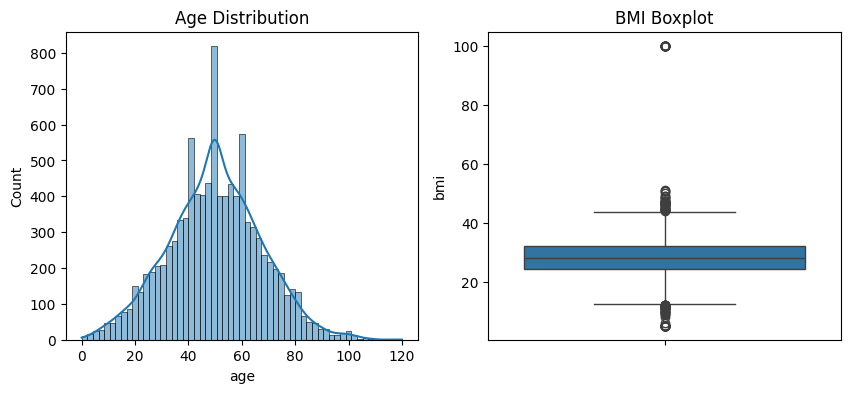

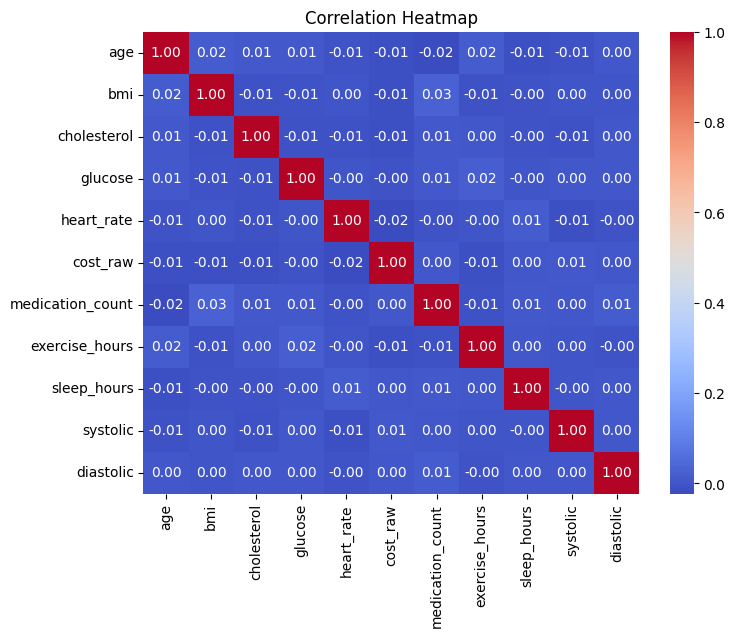

In [ ]:
# Plot age distribution and bmi boxplot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['age'], kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['bmi'])
plt.title('BMI Boxplot')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()